# Plot time series for the year at some key stations

In [1]:
import numpy as np 
import sys
import pandas as pd
import datetime as datetime    
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib as mpl
import re 
from scipy import signal #for filtering
import cmocean
print("Modules imported")

Modules imported


In [2]:
import re 
file="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/station.in"
station_id =[]
with open(file) as f:
    f.readline()
    for station in range(int(f.readline())):
        line = f.readline()
        if '!' in line:
            station_id.append(line.split('!')[-1])
        else:
            station_id.append(None)
# print(station_id)

print(len(station_id))

stations = []
for sublist in station_id:
    match = re.search(r'"(.*?)"', sublist)
    if match:
        stations.append(match.group(1).strip())
    else :
        stations.append(sublist.replace("\n", "").strip())
print(len(set(stations)))


for i, station in enumerate(stations):
    print("%d == %s" % (i+1,station))

408
379
1 == San Joaquin at Antioch
2 == Mokelumne River at Benson's Ferry
3 == Cache Slough
4 == Cache Creek at Yolo
5 == Old River at Coney Island
6 == Clifton Court
7 == Discovery Bay at Indian Slough
8 == Doughty Cut above Grant Line Canal
9 == Sacramento River at Emmaton
10 == Sacramento River at Emmaton
11 == emm upper Emmaton
12 == emm lower Emmaton
13 == Farrar Park
14 == Grant Line Canal at Tracy Rd Bridge
15 == Green's Landing
16 == Harvey O Banks PP
17 == Holland Tract
18 == Harvey O Banks PP
19 == CCWD Old River near Discovery Bay
20 == CCWD Rock Slough PP
21 == Italian Slough Headwater near Byron
22 == Jersey Point
23 == Sacramento River at Mallard Island
24 == Sacramento River at Mallard Island
25 == Middle River at Howard Rd Bridge
26 == San Joaquin at Mossdale Bridge
27 == Middle River at Tracy Blvd
28 == Old River Barrier near DMC (Above)
29 == Old River below Dam
30 == Old River at Bacon Island
31 == Old River at Head
32 == Old River at Byron
33 == Prisoners Point
34 

In [3]:
file27='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/station_files/staout_6_filt.csv'
file28='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/outputs/staout_6_filt.csv'
file29='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_29/outputs/staout_6_filt.csv'

In [4]:
#load the filtered station data
dtformat = '%Y-%m-%d %H:%M:%S'
run27=pd.read_csv(file27)
run27['datetime']=pd.to_datetime(run27['time'],format=dtformat)
run27.set_index("datetime",inplace=True)
run28=pd.read_csv(file28)
run28['datetime']=pd.to_datetime(run28['time'],format=dtformat)
run28.set_index("datetime",inplace=True)
run29=pd.read_csv(file29)
run29['datetime']=pd.to_datetime(run29['time'],format=dtformat)
run29.set_index("datetime",inplace=True)

In [5]:
run27

,time,1,2,3,4,5,6,7,8,9,...,400,401,402,403,404,405,406,407,408,409
datetime,,,,,,,,,,,,,,,,,,,,,
2018-09-01 00:00:00,2018-09-01 00:00:00,1.754273,0.063659,0.079628,-9999.0,0.169517,0.256510,0.319307,0.275117,0.513657,...,-999.0,0.078372,0.695748,0.322123,0.166981,0.233530,-9999.0,-9999.0,-9999.0,-9999.0
2018-09-01 00:15:00,2018-09-01 00:15:00,1.768724,0.063662,0.079637,-9999.0,0.169468,0.256497,0.319513,0.275033,0.528805,...,-999.0,0.078376,0.695694,0.322034,0.166936,0.233564,-9999.0,-9999.0,-9999.0,-9999.0
2018-09-01 00:30:00,2018-09-01 00:30:00,1.783468,0.063665,0.079647,-9999.0,0.169419,0.256483,0.319720,0.274951,0.544247,...,-999.0,0.078379,0.695639,0.321947,0.166891,0.233595,-9999.0,-9999.0,-9999.0,-9999.0
2018-09-01 00:45:00,2018-09-01 00:45:00,1.798504,0.063668,0.079656,-9999.0,0.169370,0.256468,0.319928,0.274872,0.559979,...,-999.0,0.078383,0.695582,0.321862,0.166846,0.233623,-9999.0,-9999.0,-9999.0,-9999.0
2018-09-01 01:00:00,2018-09-01 01:00:00,1.813827,0.063671,0.079665,-9999.0,0.169319,0.256453,0.320137,0.274795,0.575997,...,-999.0,0.078386,0.695526,0.321778,0.166801,0.233649,-9999.0,-9999.0,-9999.0,-9999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 23:00:00,2021-09-30 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-30 23:15:00,2021-09-30 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-30 23:30:00,2021-09-30 23:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


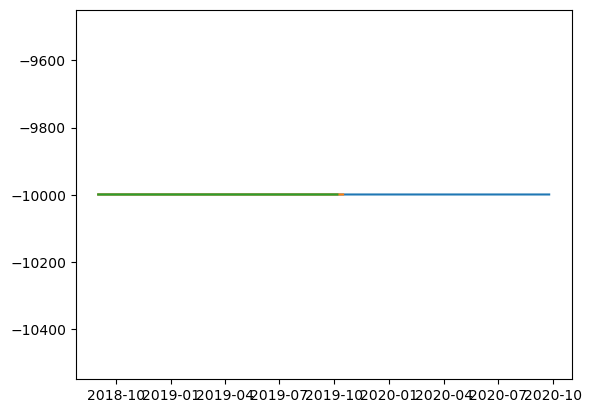

In [6]:
fig, ax = plt.subplots()
ax.plot(run27['409'])
ax.plot(run28['409'])
ax.plot(run29['409'])


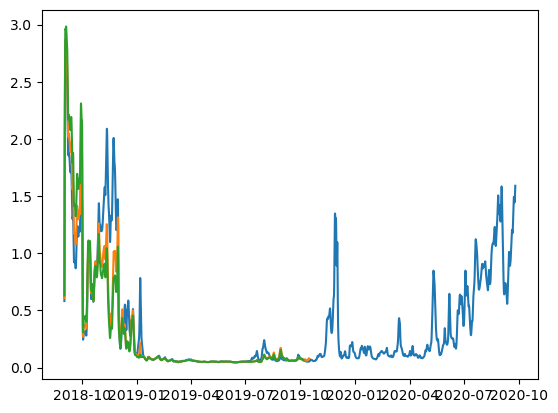

In [7]:
fig, ax = plt.subplots()
ax.plot(run27['10'])
ax.plot(run28['10'])
ax.plot(run29['10'])

# make plots for the water year for the 3 runs at 6 stations

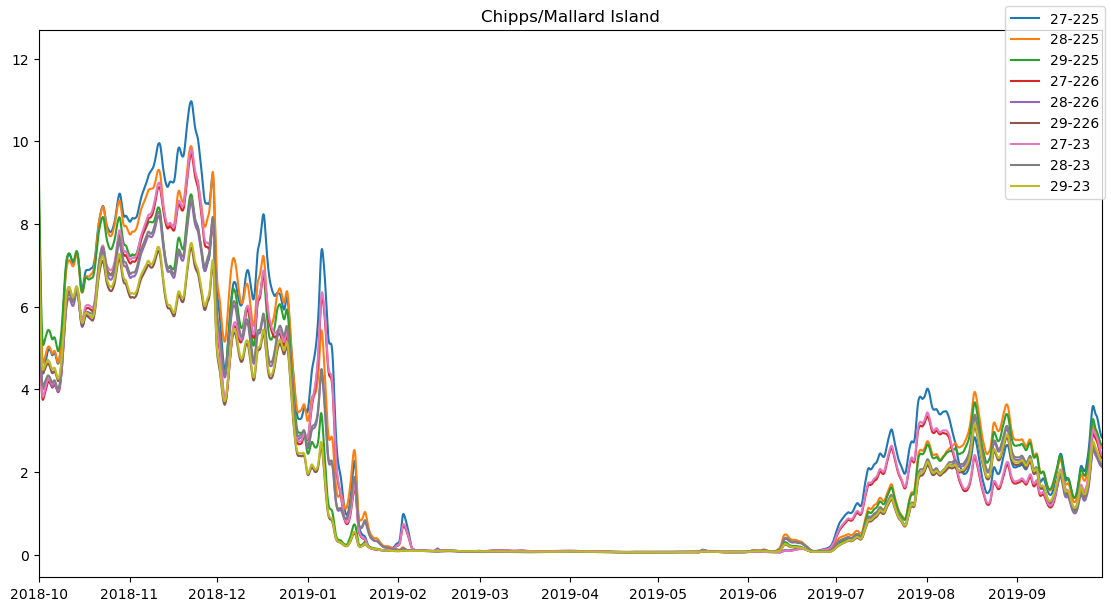

In [8]:
#chipps island: 23, 226 and 225, 225 is higher
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['225'],label='27-225')
ax.plot(run28['225'],label='28-225')
ax.plot(run29['225'],label='29-225')

ax.plot(run27['226'],label='27-226')
ax.plot(run28['226'],label='28-226')
ax.plot(run29['226'],label='29-226')

ax.plot(run27['23'],label='27-23')
ax.plot(run28['23'],label='28-23')
ax.plot(run29['23'],label='29-23')
ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('Chipps/Mallard Island')
fig.legend()

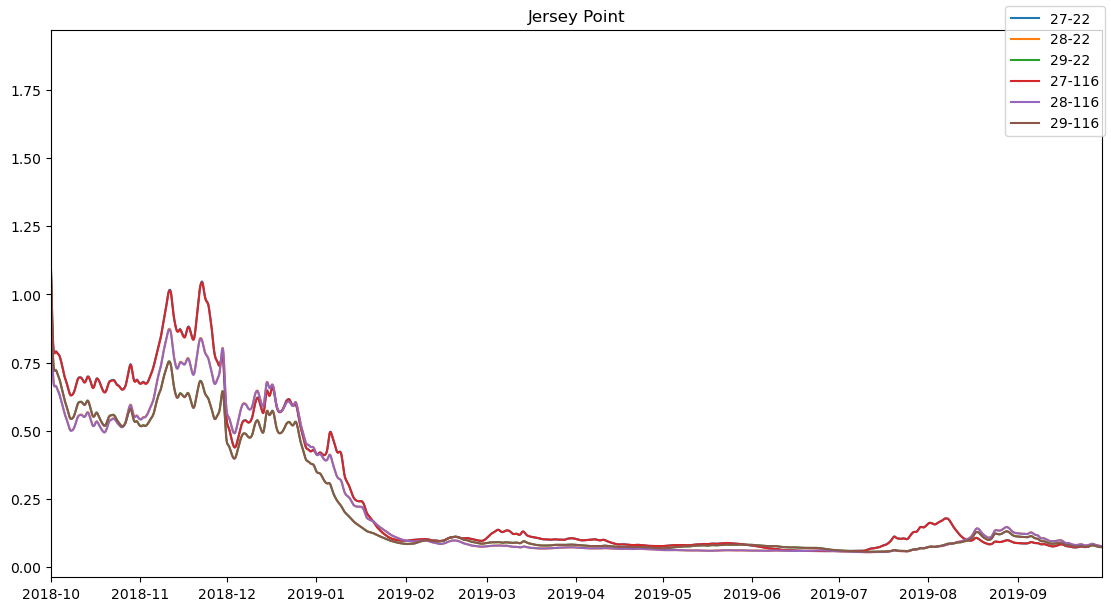

In [9]:
#Jersey Point: 22 and 116, these are the same
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['22'],label='27-22')
ax.plot(run28['22'],label='28-22')
ax.plot(run29['22'],label='29-22')

ax.plot(run27['116'],label='27-116')
ax.plot(run28['116'],label='28-116')
ax.plot(run29['116'],label='29-116')
ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('Jersey Point')
fig.legend()
plt.show()

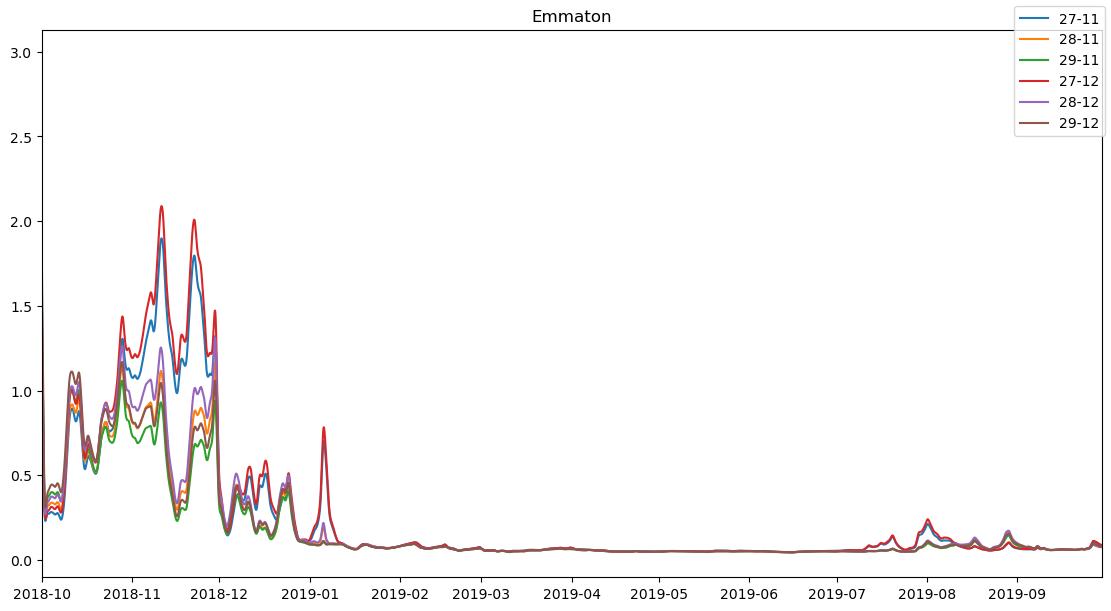

In [10]:
#Emmaton: 11 and 12, 12 is higher 
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['11'],label='27-11')
ax.plot(run28['11'],label='28-11')
ax.plot(run29['11'],label='29-11')

ax.plot(run27['12'],label='27-12')
ax.plot(run28['12'],label='28-12')
ax.plot(run29['12'],label='29-12')
ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('Emmaton')
fig.legend()
plt.show()

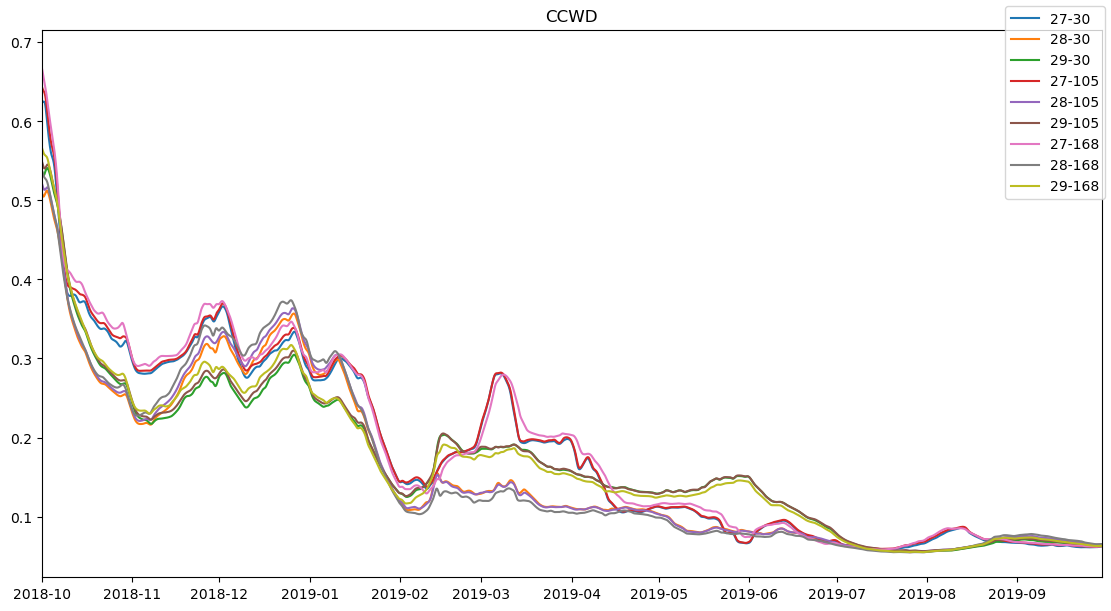

In [11]:
#CCWD: 30, 105, 168, 168 is highest, then 105, then 30
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['30'],label='27-30')
ax.plot(run28['30'],label='28-30')
ax.plot(run29['30'],label='29-30')

ax.plot(run27['105'],label='27-105')
ax.plot(run28['105'],label='28-105')
ax.plot(run29['105'],label='29-105')

ax.plot(run27['168'],label='27-168')
ax.plot(run28['168'],label='28-168')
ax.plot(run29['168'],label='29-168')
ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('CCWD')
fig.legend()
plt.show()

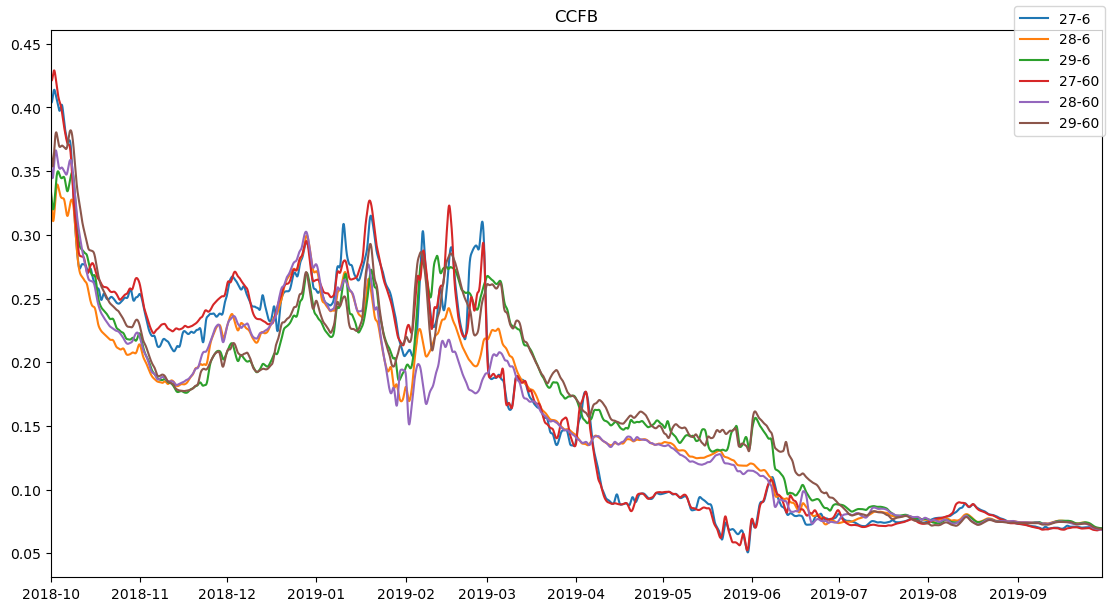

In [12]:
#CCFB: 30, 105, 168, 168 is highest, then 105, then 30
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['6'],label='27-6')
ax.plot(run28['6'],label='28-6')
ax.plot(run29['6'],label='29-6')

ax.plot(run27['60'],label='27-60')
ax.plot(run28['60'],label='28-60')
ax.plot(run29['60'],label='29-60')

ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('CCFB')
fig.legend()
plt.show()

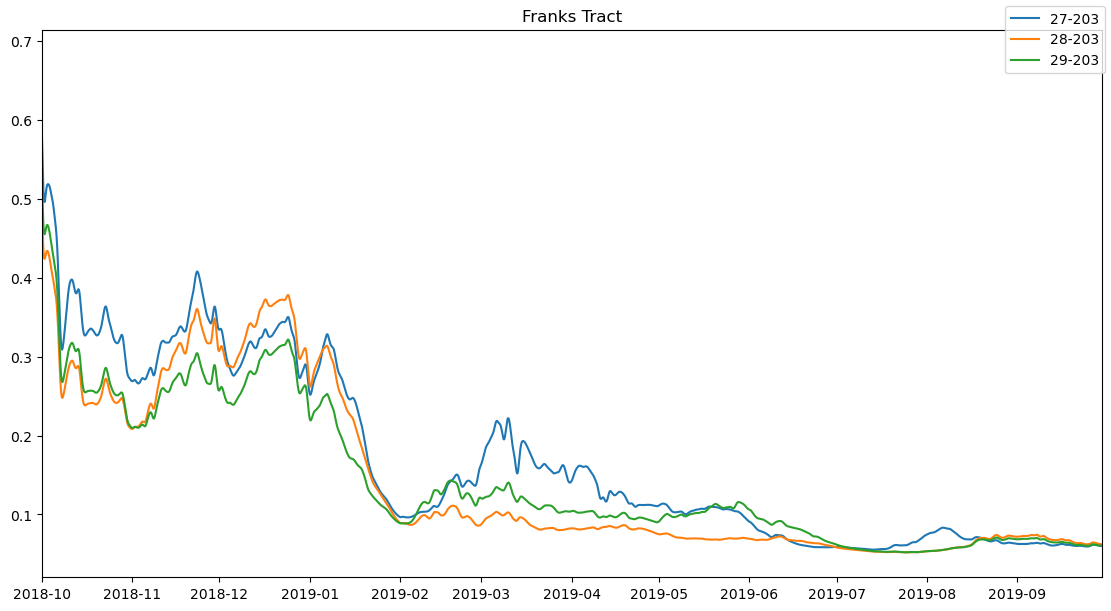

In [13]:
#Franks tract
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['203'],label='27-203')
ax.plot(run28['203'],label='28-203')
ax.plot(run29['203'],label='29-203')

ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('Franks Tract')
fig.legend()
plt.show()

# Tile 6 plots

In [14]:
import matplotlib.dates as mdates

(0, 0)
(0, 1)
(1, 0)
(1, 1)
(2, 0)
(2, 1)


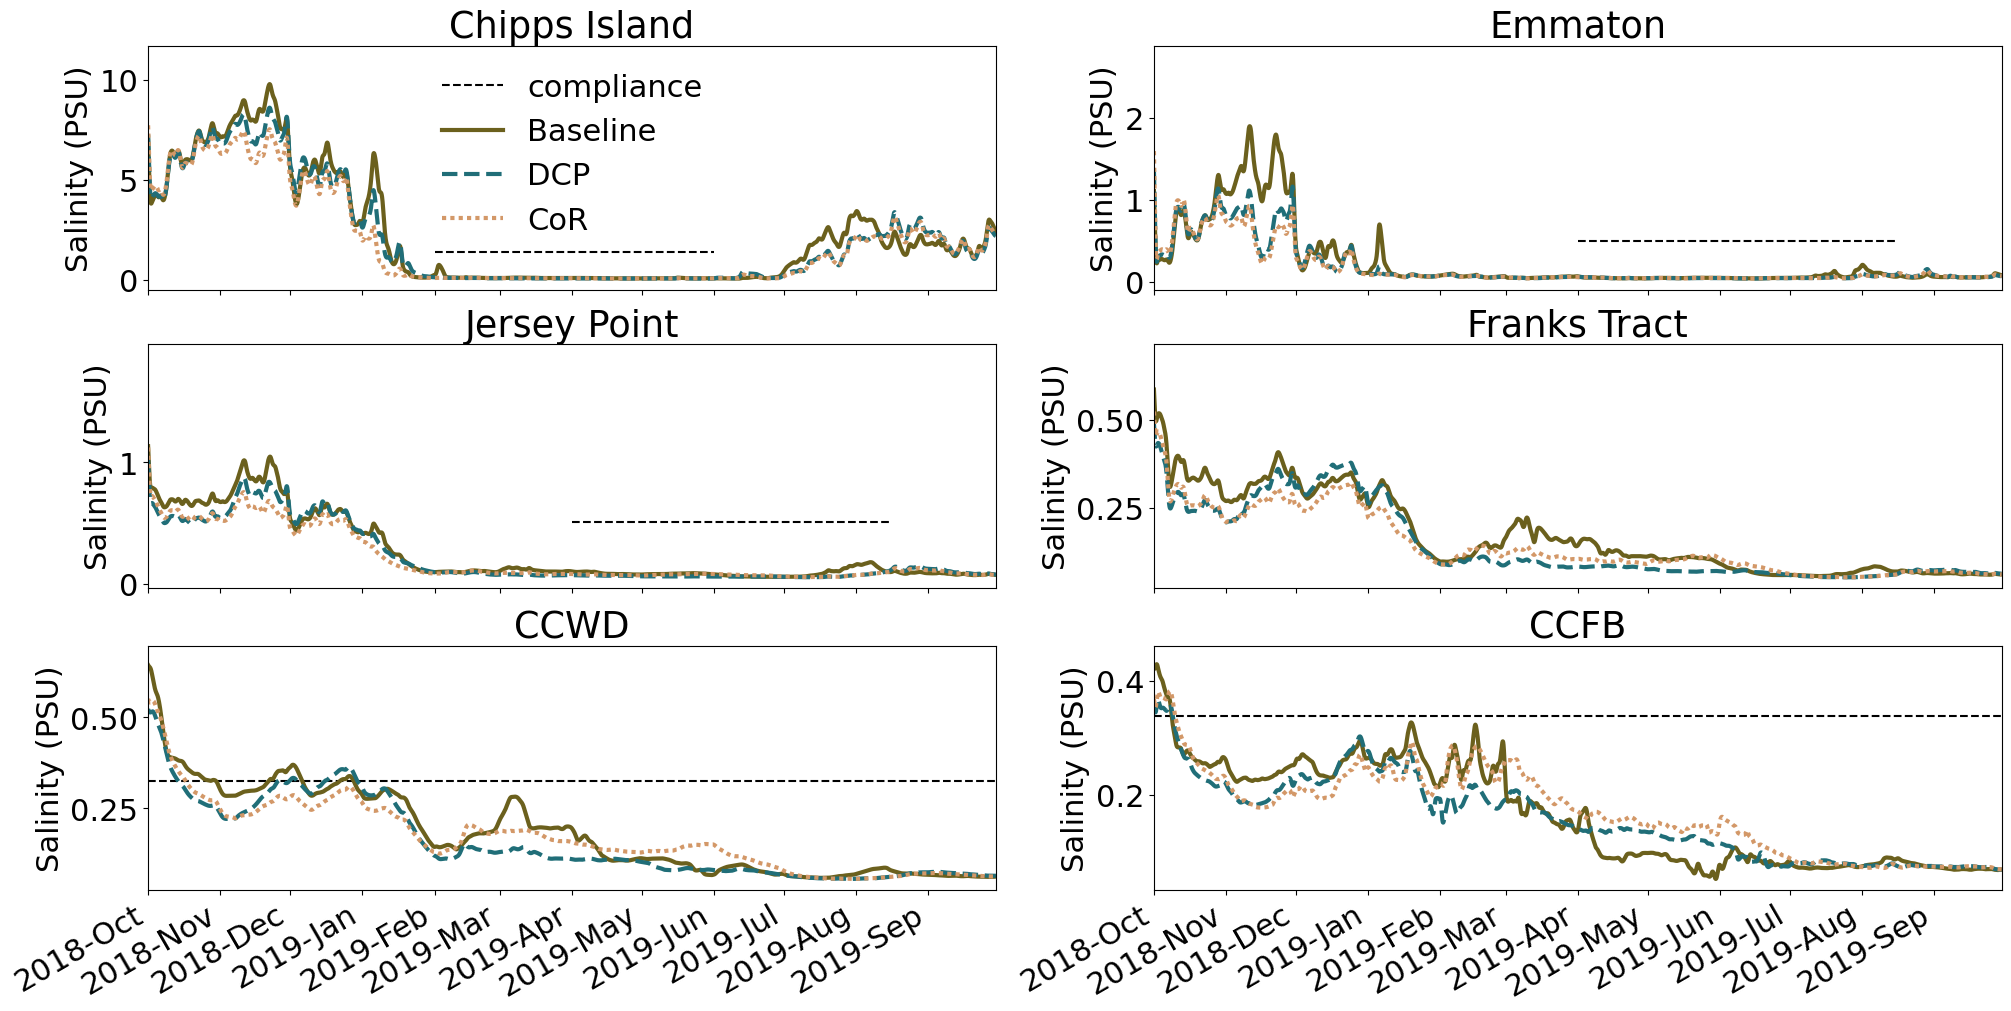

In [29]:
#station_indices=[226,22,12,168,6,203] 
#from Lily:
station_indices=[23,9,22,203,105,60]
fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(s)
    values1 = run27[str(idx)]
    values2 = run28[str(idx)]
    values3 = run29[str(idx)]
       
    ax[s].plot(values1, label = 'Baseline', linewidth=3, alpha =1, color=cmocean.cm.tarn(1/6))
    ax[s].plot(values2, label = 'DCP', linewidth=3, alpha =1,linestyle='--', color=cmocean.cm.tarn(10/12))
    ax[s].plot(values3, label = 'CoR', linewidth=3, alpha =1,linestyle=(0,(1,1)), color=cmocean.cm.tarn(2/6))
    #ax[s].set_title(stations[idx-1]) #this list is zero indexed
    ax[s].set_title(tstring)
    ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
    ax[s].set_ylabel('Salinity (PSU)')
    # Rotates and right-aligns the x labels so they don't crowd each other.

    
#ax.plot(data1.time,np.ones_like(values1)*std,linewidth=2, alpha =0.7,linestyle='--',color='k',label='Compliance')

#leg = ax.legend()
#print(ax)
#ax.set_xlim(data1.time.iloc[52000], data3.time.iloc[-1]) #July 1 to end
# ax.grid(which='major', color='b', linestyle='-')
#ax.set_title("Salinity from baroclinic run")
#ax[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d-%Y'))
ax[0,0].legend(frameon=False)
ax[2,0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,0].xaxis.get_major_locator()))
ax[2,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,0].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax[2,1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,1].xaxis.get_major_locator()))
ax[2,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,1].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

plt.show()
#fig.savefig('six_stations_timeseries_legend_2.png')

In [33]:
# what is the saltiest day at each station?
#station_indices=[226,22,12,168,6,203] 
#from Lily:
station_indices=[23,9,22,203,105,60]
# fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
# mpl.rcParams.update({'font.size': 22})
# # ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(s)
    values1 = run27[str(idx)]
    # values2 = run28[str(idx)]
    # values3 = run29[str(idx)]

    #what is the max salinity in the range set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
    maxs=values1[pd.to_datetime("2018-10-1"):pd.to_datetime("2019-9-30")].max()
    maxdate=values1[pd.to_datetime("2018-10-1"):pd.to_datetime("2019-9-30")].idxmax()
    print('Salitiest day baseline at station ' + tstring+' is '+ str(maxdate)+ ' at '+str(maxs)+ ' PSU')

(0, 0)
Salitiest day baseline at station Chipps Island is 2018-11-22 04:30:00 at 9.805315577452884 PSU
(0, 1)
Salitiest day baseline at station Emmaton is 2018-11-11 02:45:00 at 1.8983765019129044 PSU
(1, 0)
Salitiest day baseline at station Jersey Point is 2018-10-01 00:00:00 at 1.129592501538309 PSU
(1, 1)
Salitiest day baseline at station Franks Tract is 2018-10-01 00:00:00 at 0.5847631228718027 PSU
(2, 0)
Salitiest day baseline at station CCWD is 2018-10-01 00:00:00 at 0.6438533283863808 PSU
(2, 1)
Salitiest day baseline at station CCFB is 2018-10-02 04:15:00 at 0.4291041962494218 PSU


In [32]:
values1[pd.to_datetime("2018-10-1"):pd.to_datetime("2019-9-30")]

datetime
2018-10-01 00:00:00    0.424731
2018-10-01 00:15:00    0.424536
2018-10-01 00:30:00    0.424345
2018-10-01 00:45:00    0.424159
2018-10-01 01:00:00    0.423977
                         ...   
2019-09-29 23:00:00    0.068671
2019-09-29 23:15:00    0.068671
2019-09-29 23:30:00    0.068671
2019-09-29 23:45:00    0.068671
2019-09-30 00:00:00    0.068671
Name: 60, Length: 34945, dtype: float64

# below here not used

In [16]:
# #function comes from schimpy metricsplot.py script https://github.com/CADWRDeltaModeling/schimpy/blob/master/schimpy/metricsplot.py
# from vtools.data.vtime import days, hours, minutes
# from vtools.functions.filter import cosine_lanczos
# def filter_timeseries(tss, cutoff_period=hours(40)):
#     filtered = []
#     ts=tss #try removing the loop for now
#     if ts is None:
#         filtered.append(None)
#     else:
#         #print(ts)
#         ts_filtered = cosine_lanczos(ts, cutoff_period=cutoff_period)
#         ts_filtered.filtered = 'cosine_lanczos'

#     return ts_filtered

In [17]:
# import re 
# file="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/station.in"
# station_id =[]
# with open(file) as f:
#     f.readline()
#     for station in range(int(f.readline())):
#         line = f.readline()
#         if '!' in line:
#             station_id.append(line.split('!')[-1])
#         else:
#             station_id.append(None)
# # print(station_id)

# print(len(station_id))

# stations = []
# for sublist in station_id:
#     match = re.search(r'"(.*?)"', sublist)
#     if match:
#         stations.append(match.group(1).strip())
#     else :
#         stations.append(sublist.replace("\n", "").strip())
# print(len(set(stations)))


# for i, station in enumerate(stations):
#     print("%d == %s" % (i,station))

In [18]:
# def clean_staout(path2staout,path2stations,starttime,filt=True):
#     #where path2staout is the path to the station text file you want to read
#     #path2stations in the station file used to log this file
#     #starttime is a string of the form "09-10-2020 00:00:00"
#     #if filt=True the dataset is filtered
#     station_id =[]
#     with open(path2stations) as f:
#         f.readline()
#         for station in range(int(f.readline())):
#             line = f.readline()
#             if '!' in line:
#                 station_id.append(line.split('!')[-1])
#             else:
#                 station_id.append(None)
#     # print(station_id)
    
#     print(len(station_id))
    
#     stations = []
#     for sublist in station_id:
#         match = re.search(r'"(.*?)"', sublist)
#         if match:
#             stations.append(match.group(1).strip())
#         else :
#             stations.append(sublist.replace("\n", "").strip())
#     print(len(set(stations)))

#     # for i, station in enumerate(stations):
#     #     print("%d == %s" % (i,station))
#     columns = ['time']
#     stations_no = [str(i) for i in range(len(stations))]
#     columns = columns + stations_no
#     df = pd.read_csv(path2staout, sep=r'\s+', names=columns,dtype=np.float32)
#     #fill nans
#     df = df.fillna(-9999)
#     timedelta = [pd.Timedelta(i, unit = 's') for i in df.time]
#     timestamp = [pd.to_datetime(starttime) + i for i in timedelta]
#     df["time"] = timestamp
#     if filt==True:
#         df.set_index("time",inplace=True)
#         df['time'] = timestamp
#         df=df.asfreq('900s')
#         df_filt=filter_timeseries(df)
#         return df
#     else:
#         return df

In [19]:
# # 1:elev,2:air pressure,3:wind_x,4:wind_y,5:temp,6:salt,7:u,8:v,9:w
# file27="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/station_files/run_27_salinity_padded.txt"
# file28="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/outputs/staout_6"
# file29="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_29/outputs/staout_6"
# stationfile="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/station.in"
# runstarttime="08-14-2018 00:00:00"

In [20]:
# #run27=clean_staout(file27,stationfile,runstarttime)
# run28=clean_staout(file28,stationfile,runstarttime,filt=True)
# #run29=clean_staout(file29,stationfile,runstarttime)
# run28

In [21]:
# run28_raw=clean_staout(file28,stationfile,runstarttime,filt=False)

In [22]:
# run28_raw.set_index("time",inplace=True)
# run28_raw

In [23]:
# run28_raw=run28_raw.asfreq('15min')

In [24]:
# run28_filt=filter_timeseries(run28_raw)

In [25]:
# need to replace the "nan" values bc the cosine filter is not going to tolerate them as strings